In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
# import cupy
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.visualization import ImageNormalize, SqrtStretch

# import sunpy.coordinates  # NOQA
import sunpy.map
from sunpy.net import Fido
from sunpy.net import attrs as a
import sunpy.map
from matplotlib.patches import ConnectionPatch

import datetime
from scipy.io import loadmat, savemat
import scipy
from aiapy.calibrate import degradation, register, update_pointing, correct_degradation
from aiapy.calibrate.util import get_correction_table

from wavelet2DT_GPU import cwt2DT
%matplotlib inline


def calibrate_map(aia_map):
    aiamap_updated = update_pointing(aia_map)
    aiamap_registered = register(aiamap_updated)
    aiamap_calibrated = correct_degradation(aiamap_registered)/aiamap_registered.exposure_time
    return aiamap_calibrated

def transform_to_helioprojective_radial(old_map):
        # 投影到r-theta的函数
        # Calculate the number of bins in radius and azimuth
        radius_bin_size = old_map.scale[0].to_value('arcsec/pix')
        max_radius_arcsec = 1150
        num_radius_bins = int(max_radius_arcsec / radius_bin_size)
        num_azimuth_bins = 3240*2
        # Define a WCS header that uses the plate carrée cylindrical projection
        # oriented such that its pole is at disk center
        new_header = {
            'naxis': 2,
            'ctype1': 'HPLN-CAR',
            'naxis1': num_azimuth_bins,
            'cdelt1': 360 / num_azimuth_bins,
            'cunit1': 'deg',
            'crpix1': num_azimuth_bins / 2 + 0.5,
            'crval1': 0,
            'ctype2': 'HPLT-CAR',
            'naxis2': num_radius_bins,
            'cdelt2': radius_bin_size,
            'cunit2': 'arcsec',
            'crpix2': num_radius_bins + 0.5 - 90 * 3600/ (radius_bin_size),
            'crval2': -90*3600,
            'date-obs': old_map.date.utc.isot,
            'mjdref': 0,
            'dsun_obs': old_map.observer_coordinate.radius.to_value('m'),
            'hgln_obs': old_map.observer_coordinate.lon.to_value('deg'),
            'hglt_obs': old_map.observer_coordinate.lat.to_value('deg'),
            'rsun_ref': old_map.rsun_meters.value,
        }

        new_map = old_map.reproject_to(new_header)
        return new_map

def project_aia_map(squence_map):
    projected_sequence = np.array([])
    for aia_map in squence_map:
        new_map = transform_to_helioprojective_radial(aia_map)
        projected_sequence = np.append(projected_sequence, new_map)
    print('Finished: project_aia_map')
    return projected_sequence

def calibrate_aia_map_sequence(squence_map):
    calibrated_sequence = np.array([])
    num_temp = 0
    for aia_map in squence_map:
        print(num_temp)
        aiamap_calibrated = calibrate_map(aia_map)
        calibrated_sequence = np.append(calibrated_sequence, aiamap_calibrated)
        num_temp = num_temp + 1
    print('Finished: calibrate_aia_map_sequence')
    return calibrated_sequence

def save_aia_map_fits_file(aia_map_sequence, dir_aia_map='./'):
    for temp_aia_map in aia_map_sequence:
        filename = 'calibrate_aia_levl5_euv_12s_'+temp_aia_map.fits_header['DATE-OBS'][0:19].replace(':','_')+'.fits'
        temp_aia_map.save(dir_aia_map+filename)
    return 0

def get_radial_azimuth_arr(new_map):
    data_shape = np.shape(new_map.data)
    azimuth_arr = 180 + (np.arange(data_shape[1]) - new_map.fits_header['CRPIX1'])*new_map.fits_header['CDELT1'] + new_map.fits_header['CRVAL1']
    radial_degree_arr = np.flip((np.arange(data_shape[0]) - new_map.fits_header['CRPIX2'])*new_map.fits_header['CDELT2'] + new_map.fits_header['CRVAL2'])
    radial_Rs_arr = np.abs(np.tan(radial_degree_arr/180*np.pi)*new_map.fits_header['DSUN_OBS']/new_map.fits_header['RSUN_REF'])
    # print('radialRs: ',radial_Rs_arr)
    return radial_Rs_arr, azimuth_arr
    
def get_submap_data(deg_min,deg_max,r_min,r_max,new_map):
    radial_Rs_arr, azimuth_arr = get_radial_azimuth_arr(new_map)

    deg_min_index = np.argmin(np.abs(azimuth_arr-deg_min))
    deg_max_index = np.argmin(np.abs(azimuth_arr-deg_max))
    r_min_index = np.argmin(np.abs(radial_Rs_arr-r_min))
    r_max_index = np.argmin(np.abs(radial_Rs_arr-r_max))
    new_map_data = np.flip(np.copy(new_map.data), axis=0)
    if deg_max_index >= deg_min_index:
        submap_data = new_map_data[r_min_index:r_max_index+1,deg_min_index:deg_max_index+1]
        sub_radial_Rs_arr = radial_Rs_arr[r_min_index:r_max_index+1]
        sub_azimuth_arr = azimuth_arr[deg_min_index:deg_max_index+1]
    else:
        submap_data = np.concatenate((new_map_data[r_min_index:r_max_index+1,deg_min_index:],new_map_data[r_min_index:r_max_index+1,:(deg_max_index+1)]), axis=1)
        sub_radial_Rs_arr = radial_Rs_arr[r_min_index:r_max_index+1]
        sub_azimuth_arr = np.concatenate((azimuth_arr[deg_min_index:], azimuth_arr[:(deg_max_index+1)]), axis=0)
    return sub_radial_Rs_arr, sub_azimuth_arr, submap_data

def crop_lasco_map(squence_map,deg_min,deg_max,r_min,r_max):
    # crop_lasco_map(self, sequence, deg_min=60, deg_max = 120, r_min = 2.4, r_max = 6.3, ):
    # 裁剪出所选区域
    # deg_min = self.phiMin.value()#float(self.phiMin.toPlainText())
    # deg_max = self.phiMax.value()#float(self.phiMax.toPlainText())
    # r_min = self.radialMin.value()#float(self.radialMin.toPlainText())
    # r_max = self.radialMax.value()#float(self.radialMax.toPlainText())
    subsequence_data_is_empty = True
    sequence_map_datetime = np.array([])
    for map_idx in range(np.shape(squence_map)[0]):
        temp_map = squence_map[map_idx]
        sub_radial_Rs_arr, sub_azimuth_arr, submap_data = get_submap_data(deg_min = deg_min,
                                                                            deg_max = deg_max,
                                                                            r_min = r_min,
                                                                            r_max = r_max, 
                                                                            new_map = temp_map)
        map_datetime = datetime.datetime.strptime(temp_map.date.utc.isot,"%Y-%m-%dT%H:%M:%S.%f")
        
        if subsequence_data_is_empty:
            subsequence_data = np.copy(submap_data)
            subsequence_data_is_empty = False
            sequence_map_datetime = np.append(sequence_map_datetime, map_datetime)
        else:
            subsequence_data = np.dstack([subsequence_data, submap_data])
            sequence_map_datetime = np.append(sequence_map_datetime, map_datetime)
    print('Finished: crop_lasco_map')
    return sub_radial_Rs_arr, sub_azimuth_arr, sequence_map_datetime, subsequence_data

def calculate_wavelet_2DT_GPU(input_data_3D):
    # if input_data_3D==0:
    #     load_data_file = loadmat("D:/work/wavelet/data/wavelet_input/wavelet_input_aia171.mat")
    #     input_data_3D = load_data_file['data'][...]
    #     input_data_3D = np.sqrt(input_data_3D)
    # sequence_time = load_data_file['crop_sequence_jualin_time'][...]
    dx = 1 # load_data_file['dx'][-1][0]
    dy = 1 # load_data_file['dy'][-1][0]
    dt = 12
    # input_data_3D = np.transpose(sequence_data, (1,0,2))
    fft_3D_out = scipy.fft.fftn(input_data_3D, axes=(0,1,2)) #fft变换结果数组shape和原数据保持一致
    
    freq_sample_spatial_x = 1.0/dx
    freq_sample_spatial_y = 1.0/dy
    freq_sample_spatial_t = 1.0/dt

    lambda_r_arr = np.logspace(np.log10(2),np.log10(50), 10, base=10)*4 ### modified by user
    lambda_t_arr = np.logspace(np.log10(2),np.log10(15), 5, base=10) ### modified by user
    period_arr = np.logspace(np.log10(24),np.log10(600), 24, base=10) ### modified by user

    # lambda_r_arr = np.hstack((np.flip(-lambda_r_arr), lambda_r_arr))
    # lambda_t_arr = np.hstack((np.flip(-lambda_t_arr), lambda_t_arr))
    lambda_r_arr = np.hstack((-lambda_r_arr, np.flip(lambda_r_arr)))
    
    # period_arr=  np.append(period_arr, -1500)
    lambda_t_arr = 1/np.sort(1/np.linspace(-100, 100, 10))

    dlambda_theta = np.abs(np.append(0, np.diff(lambda_t_arr)))

    k_lambda_r = 5
    step_lambda_r = int(np.ceil(lambda_r_arr.size/k_lambda_r))
    k_lambda_t = 5
    step_lambda_t = int(np.ceil(lambda_t_arr.size/k_lambda_t))
    k_period = 8
    step_period = int(np.ceil(period_arr.size/k_period))
    
    for i_lambda_r in range(k_lambda_r):
        for i_lambda_t in range(k_lambda_t):
            for i_period in range(k_period):
                # for i_rot_angle in range(k_rot_angle):
                input_lambda_r_arr = lambda_r_arr[step_lambda_r*i_lambda_r:step_lambda_r*(i_lambda_r+1)]
                input_lambda_t_arr = lambda_t_arr[step_lambda_t*i_lambda_t:step_lambda_t*(i_lambda_t+1)]
                input_period_arr = period_arr[step_period*i_period:step_period*(i_period+1)]
                input_dlambda_theta = dlambda_theta[step_lambda_t*i_lambda_t:step_lambda_t*(i_lambda_t+1)]
                # input_rot_angle_arr = rot_angle_arr[step_rot_angle*i_rot_angle:step_rot_angle*(i_rot_angle+1)]
                ## 作2D+T的morlet小波变换
                output_2DT_partial = cwt2DT(fft_3D_out,
                                   freq_sample_spatial_x=freq_sample_spatial_x,
                                   freq_sample_spatial_y=freq_sample_spatial_y,
                                   freq_sample_time=freq_sample_spatial_t,
                                   lambda_t_arr=input_lambda_t_arr, lambda_r_arr=input_lambda_r_arr, period_arr=input_period_arr,
                                   ) #  unit of angle: degree
                # dk_theta = np.abs(np.append(np.diff(2*np.pi/input_lambda_t_arr), 0))
                dim_array = np.ones((1, output_2DT_partial.ndim), int).ravel()
                dim_array[3] = -1
                input_dlambda_theta_reshaped = input_dlambda_theta.reshape(dim_array)

                # output_2DT_partial_intergrated_on_k_theta = np.sum(np.abs(output_2DT_partial)**2 * input_dlambda_theta_reshaped, axis=3)
                output_2DT_partial_intergrated_on_k_theta = np.sum(np.abs(output_2DT_partial)**2, axis=3)

                dtime = 1 # unit: frame
                output_2DT_partial_intergrated_on_k_theta_low_time_cadence = output_2DT_partial_intergrated_on_k_theta[:,:,::dtime,:,:]
                mdic = {"data": output_2DT_partial_intergrated_on_k_theta_low_time_cadence, "input_lambda_r_arr": input_lambda_r_arr,
                        "input_lambda_t_arr": input_lambda_t_arr,
                         "input_period_arr": input_period_arr, 
                         }

                print(np.shape(output_2DT_partial_intergrated_on_k_theta))
                savemat("D:/work/wavelet/data/wavelet_output/output_2DT_partial_"+str(i_lambda_r)+"_lambda_r_"+str(i_lambda_t)+"_lambda_t_"+str(i_period)+"_period.mat", mdic)
                print("D:/work/wavelet/data/wavelet_output/output_2DT_partial_"+str(i_lambda_r)+"_lambda_r_"+str(i_lambda_t)+"_lambda_t_"+str(i_period)+"_period.mat")
                del mdic
                del output_2DT_partial

def get_parameter_index_in_np_array(array, sub_array):
    sub_idx = np.array([],dtype=int)
    for i in sub_array:
        idx_temp = int(np.argmin(np.abs(array-i)))
        if np.abs(array[idx_temp] - i)<1e-3:
            sub_idx = np.append(sub_idx, idx_temp)
        else:
            print('Wrong: get_parameter_index_in_np_array!')
        
    return sub_idx

def combine_wavelet_output(azimuth_degree,radial_Rs):

    dir_wavelet_output = 'D:/work/wavelet/data/wavelet_output/'
    wavelet_output_filelist = os.listdir(dir_wavelet_output)
    current_point_is_in_wavelet_output, azimuth_idx, radial_idx, x_azimuth_arr, y_radial_arr = \
                        check_current_point_is_in_wavelet_output(azimuth_degree, radial_Rs)
    print(azimuth_idx)
    azimuth_idx = 41 ## added by HCP
    print('current_point_is_in_wavelet_output',current_point_is_in_wavelet_output)
    if current_point_is_in_wavelet_output:
        lambda_r_arr = np.logspace(np.log10(2),np.log10(50), 10, base=10)*4 ### modified by user
        lambda_t_arr = np.logspace(np.log10(2),np.log10(15), 5, base=10) ### modified by user
        period_arr = np.logspace(np.log10(24),np.log10(600), 24, base=10) ### modified by user

        # lambda_r_arr = np.hstack((np.flip(-lambda_r_arr), lambda_r_arr))
        # lambda_t_arr = np.hstack((np.flip(-lambda_t_arr), lambda_t_arr))
        lambda_r_arr = np.hstack((-lambda_r_arr, np.flip(lambda_r_arr)))
    
        # period_arr=  np.append(period_arr, -1500)
        lambda_t_arr =  1/np.sort(1/np.linspace(-100, 100, 10))
        
        # data_combined = np.zeros(shape=(y_radial_arr.size, 51, lambda_r_arr.size, period_arr.size)) ## 13??
        data_combined = np.zeros(shape=(151,101, lambda_r_arr.size, period_arr.size)) ## 13??
        
        for file in wavelet_output_filelist:
            print(file)
            wavelet_output = loadmat(dir_wavelet_output+file)
            data_5D = wavelet_output['data']
            sub_lambda_r_arr = wavelet_output['input_lambda_r_arr'][-1]
            sub_lambda_t_arr = wavelet_output['input_lambda_t_arr'][-1]
            
            # if np.abs(sub_lambda_t_arr[0])>10.01 or np.abs(sub_lambda_t_arr[-1])>10.01:## added by HCP
            #     print(sub_lambda_t_arr)
            #     continue## added by HCP
            sub_period_arr = wavelet_output['input_period_arr'][-1]
            sub_lambda_r_idx_arr = get_parameter_index_in_np_array(lambda_r_arr, sub_lambda_r_arr)
            sub_lambda_t_idx_arr = get_parameter_index_in_np_array(lambda_t_arr, sub_lambda_t_arr)
            sub_period_idx_arr = get_parameter_index_in_np_array(period_arr, sub_period_arr)
            
            data_combined[:, :, sub_lambda_r_idx_arr[0]:sub_lambda_r_idx_arr[-1]+1, sub_period_idx_arr[0]:sub_period_idx_arr[-1]+1] = \
            data_combined[:, :, sub_lambda_r_idx_arr[0]:sub_lambda_r_idx_arr[-1]+1, sub_period_idx_arr[0]:sub_period_idx_arr[-1]+1] + \
                                                np.mean(data_5D[50:51, :, :, :, :], axis=(0))# theta, radial, time, kr, w
            #data_combined[:, :, sub_lambda_r_idx_arr[0]:sub_lambda_r_idx_arr[-1]+1, sub_period_idx_arr[0]:sub_period_idx_arr[-1]+1] =data_5D[azimuth_idx, :, :,0, :, :]
        mdic = {"data": data_combined,"radial_arr": y_radial_arr,
                                     "lambda_r_arr": lambda_r_arr,
                                     "lambda_t_arr": lambda_t_arr, 
                                     "period_arr": period_arr}
        # time_datetime_str  = datetime.datetime.strftime(time_datetime, "%Y_%m_%d_%H_%M_%S")
        dir_combined_wavelet_output = 'D:/work/wavelet/data/wavelet_output_combined/'
        filename_of_combined_wavelet_output = 'combined_wavelet_output_azimuth_' + str(azimuth_degree) + '_'+'radial_' + str(radial_Rs) + '.mat'
        print(dir_combined_wavelet_output + filename_of_combined_wavelet_output)
        savemat(dir_combined_wavelet_output + filename_of_combined_wavelet_output, mdic)
    else:
        print('Please choose another point!')

def check_current_point_is_in_wavelet_output(azimuth_degree, radial_Rs):
    date_filename = "D:/work/wavelet/data/wavelet_input/wavelet_input_aia171.mat"
    sub_sequence_data_mat = loadmat(date_filename)
    y_radial_arr = sub_sequence_data_mat['y_radial_arr'][-1]
    x_azimuth_arr = sub_sequence_data_mat['x_azimuth_arr'][-1]
    azimuth_index = np.argmin(np.abs(x_azimuth_arr-azimuth_degree))
    radial_index = np.argmin(np.abs(y_radial_arr-radial_Rs))
    if x_azimuth_arr[0] <= x_azimuth_arr[-1]:
        if (azimuth_degree > x_azimuth_arr[0]) and  (azimuth_degree< x_azimuth_arr[-1]) and (radial_Rs > y_radial_arr[0]) and (radial_Rs < y_radial_arr[-1]):
            current_point_is_in_wavelet_output = True
            return current_point_is_in_wavelet_output, azimuth_index, radial_index, x_azimuth_arr, y_radial_arr
        else:
            current_point_is_in_wavelet_output = False
            return current_point_is_in_wavelet_output, azimuth_index, radial_index, x_azimuth_arr, y_radial_arr
    else:
        if ((azimuth_degree > x_azimuth_arr[0] and azimuth_degree <= 360.0) or (azimuth_degree >= 0.0 and azimuth_degree < x_azimuth_arr[-1])) and (radial_Rs > y_radial_arr[0]) and (radial_Rs < y_radial_arr[-1]):
            current_point_is_in_wavelet_output = True
            return current_point_is_in_wavelet_output, azimuth_index, radial_index, x_azimuth_arr, y_radial_arr
        else:
            current_point_is_in_wavelet_output = False
            return current_point_is_in_wavelet_output, azimuth_index, radial_index, x_azimuth_arr, y_radial_arr
def save_current_crop_sequence_data(sub_radial_Rs_arr, sub_azimuth_arr, crop_sequence_data):
        saved_crop_data = np.transpose(crop_sequence_data, (1,0,2))  ## make sure that the shape and order of croped data are correct.
        use_diff_image = False
        if use_diff_image:
            saved_crop_data_diff = np.diff(saved_crop_data, axis=2)
        else:
            saved_crop_data_diff = np.copy(saved_crop_data)
            
        data_shape = np.shape(saved_crop_data_diff)
        # crop_sequence_jualin_time = np.array([])
        # for i in crop_sequence_datetime_interp:
        #     crop_sequence_jualin_time = np.append(crop_sequence_jualin_time, julian.to_jd(i))
        if use_diff_image:
            mdic = {"data": saved_crop_data_diff,
                   "data_shap":data_shape,'x_azimuth_arr':sub_azimuth_arr,'y_radial_arr':sub_radial_Rs_arr}
        else:
           mdic = {"data": saved_crop_data_diff,
                   "data_shap":data_shape,'x_azimuth_arr':sub_azimuth_arr,'y_radial_arr':sub_radial_Rs_arr}
           
        crop_data_filename = "D:/work/wavelet/data/wavelet_input/wavelet_input_aia171.mat"
        savemat(crop_data_filename, mdic)
        print(crop_data_filename)
        
        content_log = 'Saved file: ' + crop_data_filename
        print(content_log)
        
import numpy as np
from scipy import fftpack,signal

def build_atrous_coef(j, method):
    if method == 'B_spline':
        if j == 0:
            atrous_coef = np.matrix([1/16.0, 1/4.0, 3/8.0, 1/4.0, 1/16.0])
            return np.array(np.matmul(atrous_eff.T, atrous_eff))
        elif j >= 1:
            len_atrous_eff = 5 + 2**(j+1)
            atrous_coef = np.zeros(len_atrous_eff)
            atrous_coef[0] = 1/16.0
            atrous_coef[int(2**(j-1)+1)] = 1/4.0
            atrous_coef[int((len_atrous_eff-1)/2)] = 3/8.0
            atrous_coef[int(3*2**(j-1)+3)] = 1/4.0
            atrous_coef[-1] = 1/16.0
            atrous_coef = np.matrix(atrous_coef)
            return np.array(np.matmul(atrous_coef.T, atrous_coef))
        else:
            print("Please input a positive integer")
    elif method == 'linear':
        if j == 0:
            atrous_coef = np.matrix([0.25,0.5,0.25])
            return np.array(np.matmul(atrous_eff.T, atrous_eff))
        elif j >= 1:
            len_atrous_eff = 3 + 2**j
            atrous_coef = np.zeros(len_atrous_eff)
            atrous_coef[0] = 0.25
            atrous_coef[int((len_atrous_eff-1)/2)] = 0.5
            atrous_coef[-1] = 0.25
            atrous_coef = np.matrix(atrous_coef)
            return np.array(np.matmul(atrous_coef.T, atrous_coef))
        else:
            print("Please input a positive integer")
    else:
        print("choose a method: 'B_spline' or 'linear'")
        
def a_trous_wavelet_2D(input_data, level_num, method='B_spline'):
    if method == 'B_spline':
        if level_num == 1:
            len_atrous_coef = 5
        elif level_num >= 2:
            len_atrous_coef = 5 + 2**(level_num)
        else:
            print("Please input a positive integer")
    elif method == 'linear':
        if level_num == 1:
            len_atrous_coef = 3
        elif level_num >= 2:
            len_atrous_coef = 3 + 2**(level_num-1)
        else:
            print("Please input a positive integer")
    else:
        print("choose a method: 'B_spline' or 'linear'")
        return 0
        
    data_shape = np.shape(input_data)

    if np.min(data_shape) > len_atrous_coef:
        output_c = np.empty(shape=(data_shape[0],data_shape[1],level_num))
        wavelet_coef = np.empty(shape=(data_shape[0],data_shape[1],level_num))
        output_c[:,:,0] = np.copy(input_data)
        for i in range(1,level_num):
            output_c[:,:,i] = signal.convolve(input_data, build_atrous_coef(i, method), mode = "same")
        wavelet_coef[:,:,:-1] = -np.diff(output_c, axis=2)
        wavelet_coef[:,:,-1] = np.copy(output_c[:,:,-1])
        return wavelet_coef
    else:
        print('Please reduce the number of level')

def enhenced_map_sequence(sequence_data):
    enhenced_sequence_data = np.copy(sequence_data)
    for i in range(np.shape(sequence_data)[2]):
        input_data = sequence_data[:,:,i]
        output_w = a_trous_wavelet_2D(input_data, level_num=4, method='B_spline')
        enhenced_sequence_data[:,:,i] = output_w[:,:,1] + output_w[:,:,2] 
    return enhenced_sequence_data
 

c:\Users\hcp\.conda\envs\work_solo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [63]:
# download AIA full disk map
start_time = Time('2012-03-27T18:25:00', scale='utc', format='isot')
wavelength = '171'
jsoc_email = 'chuanpeng.hou@pku.edu.cn'
query = Fido.search(
    a.Time(start_time - 0*u.s, start_time + 20*60*u.s),
    a.Wavelength(int(wavelength)*u.angstrom),
    a.Sample(12*u.s),
    a.jsoc.Series.aia_lev1_euv_12s,
    a.jsoc.Notify(jsoc_email),
    a.jsoc.Segment.image,
)
dir_files = 'D:/work/wavelet/data/AIA_20min_1825/' + wavelength + '/'
files = Fido.fetch(query, path=dir_files, overwrite=True)
sequence_raw = sunpy.map.Map(files, sequence=True)
# files = list(np.sort(os.listdir(dir_files)))
# sequence_raw = []
# for file in files:
#     sequence_raw.append(sunpy.map.Map(dir_files+file))



# calibrate AIA map
calibrated_sequence = calibrate_aia_map_sequence(sequence_raw)
# calibrated_sequence = sequence_raw
save_aia_map_fits_file(calibrated_sequence, dir_aia_map='D:/work/wavelet/data/AIA_20min_1825/calibrate_171/')

# # transform to radial_theta coordinate
# projected_sequence = project_aia_map(calibrated_sequence)

# # crop map sequence
# sub_radial_Rs_arr, sub_azimuth_arr, sequence_map_datetime, subsequence_data =\
#             crop_lasco_map(projected_sequence, deg_min=357, deg_max=4, r_min=1.01, r_max=1.07)

# # save croped map sequence
# save_current_crop_sequence_data(sub_radial_Rs_arr, sub_azimuth_arr, subsequence_data)

# # wavelet map sequence
# calculate_wavelet_2DT_GPU()

# # combine wavelet results
# azimuth_degree = 0.3
# radial_Rs = 1.05 # can be ignored
# # time_datetime = datetime.datetime(2023,11,14,0,0,0)

# # combine_wavelet_output(azimuth_degree, radial_Rs)

# # visualize results
# wavelet_output_combined_data = loadmat('D:/work/wavelet/data/wavelet_output_combined/combined_wavelet_output_azimuth_0.3_radial_1.05.mat')
# wavelet_output_data = wavelet_output_combined_data['data']
# print(wavelet_output_combined_data.keys())
# lambda_r_arr = wavelet_output_combined_data['lambda_r_arr'][-1]
# period_arr = wavelet_output_combined_data['period_arr'][-1]

# omega_arr = 1/(period_arr)
# wavevector_arr = 1/(lambda_r_arr * 0.0012445220250452197/2 * 695)
# # wavelet_ouput_plot = np.log10(np.mean(wavelet_output_data[40:65,40:65, :, :], axis=(0,1)))
# wavelet_ouput_plot = np.log10(wavelet_output_data[60, 50, :, :])
# wavevector_grid, omega_grid = np.meshgrid(wavevector_arr, omega_arr, indexing='ij')
# ax = plt.subplot()
# plt.tripcolor(wavevector_grid.reshape(-1), omega_grid.reshape(-1), wavelet_ouput_plot.reshape(-1), cmap='jet',vmax=0.5)
# # plt.ylim([0.00225,0.025])
# # plt.xlim([-0.08,0.08])
# # plt.yscale('log')
# # plt.xscale('symlog')
# # plt.title('r = ' + '%3.2f'%(sub_radial_Rs_arr[90]) + ' Rs')
# plt.xlabel(r'$k_{r}$  $ [2\pi/R_s]$')
# plt.ylabel(r'$\omega$  $[2\pi/s]$')
# # plt.pcolor(wavevector_arr,omega_arr,wavelet_ouput_plot, cmap='jet')
# # ax.axes_ratio('square')
 

Export request pending. [id=JSOC_20240614_003005, status=2]
Waiting for 0 seconds...
Export request pending. [id=JSOC_20240614_003005, status=1]
Waiting for 5 seconds...
Export request pending. [id=JSOC_20240614_003005, status=1]
Waiting for 5 seconds...
Export request pending. [id=JSOC_20240614_003005, status=1]
Waiting for 5 seconds...
Export request pending. [id=JSOC_20240614_003005, status=1]
Waiting for 5 seconds...
Export request pending. [id=JSOC_20240614_003005, status=1]
Waiting for 5 seconds...
Export request pending. [id=JSOC_20240614_003005, status=1]
Waiting for 5 seconds...
Export request pending. [id=JSOC_20240614_003005, status=1]
Waiting for 5 seconds...
101 URLs found for download. Full request totalling 1189MB


Files Downloaded: 100%|██████████| 101/101 [15:14<00:00,  9.06s/file]


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
Finished: calibrate_aia_map_sequence


0

In [2]:
dir_aia_map = 'D:/work/wavelet/data/AIA_20min_1825/calibrate_171/'
files = list(np.sort(os.listdir(dir_aia_map)))
calibrate_sequence_map = []

for file in files:
    print(file)
    temp_map = sunpy.map.Map(dir_aia_map+file)
    # input_data = temp_map.data
    # output_w = a_trous_wavelet_2D(input_data, level_num=4, method='linear')
    # enhenced_data = output_w[:,:,1] + output_w[:,:,2] 
    # calibrate_sequence_map.append(sunpy.map.Map(enhenced_data, temp_map.fits_header))
    calibrate_sequence_map.append(temp_map)

calibrate_sequence_submap = np.array([])
for temp_map in calibrate_sequence_map:
    bottom_left = SkyCoord(-30*u.arcsec, 970*u.arcsec,  frame=temp_map.coordinate_frame)
    top_right = SkyCoord(30*u.arcsec, 1150*u.arcsec,  frame=temp_map.coordinate_frame)
    calibrate_sequence_submap = np.append(calibrate_sequence_submap, temp_map.submap(bottom_left, top_right=top_right))

# del calibrate_sequence_map

subsequence_data_is_empty = True
for map_idx in range(np.shape(calibrate_sequence_submap)[0]):
    temp_map = calibrate_sequence_submap[map_idx]
    if subsequence_data_is_empty:
        subsequence_data = np.copy(temp_map.data[::2,::1])
        print('np.shape(temp_map.data)',np.shape(temp_map.data))
        subsequence_data_is_empty = False
    else:
        subsequence_data = np.dstack([subsequence_data, temp_map.data[::2,::1]])

for idx in range(np.shape(subsequence_data)[2]):
    subsequence_data[:,:,idx] = subsequence_data[:,:,idx] - np.mean(subsequence_data, axis=(2))

# a trous data
# enhenced_sequence_data = enhenced_map_sequence(sequence_data=subsequence_data)

# wavelet map sequence
input_data_3D = np.transpose(subsequence_data, (1,0,2))
# calculate_wavelet_2DT_GPU(input_data_3D=input_data_3D)

# # combine wavelet results
# azimuth_degree = 358 # 358
# radial_Rs = 1.05 # can be ignored

# combine_wavelet_output(azimuth_degree, radial_Rs)

# # visualize results
# wavelet_output_combined_data = loadmat('D:/work/wavelet/data/wavelet_output_combined/combined_wavelet_output_azimuth_358_radial_1.05.mat')
# wavelet_output_data = wavelet_output_combined_data['data']
# print(wavelet_output_combined_data.keys())
# lambda_r_arr = wavelet_output_combined_data['lambda_r_arr'][-1]
# period_arr = wavelet_output_combined_data['period_arr'][-1]

# omega_arr = 1/(period_arr)
# wavevector_arr = 1/(lambda_r_arr * 1.2 * 0.721)
# wavelet_ouput_plot = np.log10(np.mean(wavelet_output_data[15:-15, 30:-30, :,:], axis=(0,1)))

# wavevector_grid, omega_grid = np.meshgrid(wavevector_arr, omega_arr, indexing='ij')
# ax = plt.subplot()
# plt.tricontourf(wavevector_grid.reshape(-1), omega_grid.reshape(-1), wavelet_ouput_plot.reshape(-1), cmap='jet',levels=30)
# plt.colorbar()
# plt.ylim([0,0.02])
# plt.xlim([-0.05,0.05])
# plt.plot(np.array([0,0]),np.array([0,0.2]),'k')
# k = 0.56
# plt.plot(np.array([0,0.02]),k*np.array([0,0.02]),'k--')
# # plt.yscale('log')
# # plt.xscale('symlog')
# # plt.title('r = ' + '%3.2f'%(sub_radial_Rs_arr[90]) + ' Rs')
# plt.title('r: 1.03Rs~1.18Rs\n theta: -30"~30"\n T: 2012-03-27 18:31:12~18:39:24')
# plt.text(0.025,0.0085,'V = 440km/s',color='white')
# plt.xlabel(r'$k_{r}$  $ [1/Mm]$')
# plt.ylabel(r'$\omega$  $[Hz]$')
# # plt.pcolor(wavevector_arr,omega_arr,wavelet_ouput_plot, cmap='jet')
# # ax.axes_ratio('square'); 
# plt.savefig('D:/work/wavelet/figure/without_a_trous_figure1.png',dpi=300,bbox_inches='tight')
# # ax.set_aspect(50)

calibrate_aia_levl5_euv_12s_2012-03-27T18_25_12.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_25_24.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_25_36.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_25_48.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_26_00.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_26_12.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_26_24.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_26_36.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_26_48.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_27_00.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_27_12.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_27_24.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_27_36.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_27_48.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_28_00.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_28_12.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_28_24.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_28_36.fits
calibrate_aia_levl5_euv_12s_2012-03-27T18_28_4

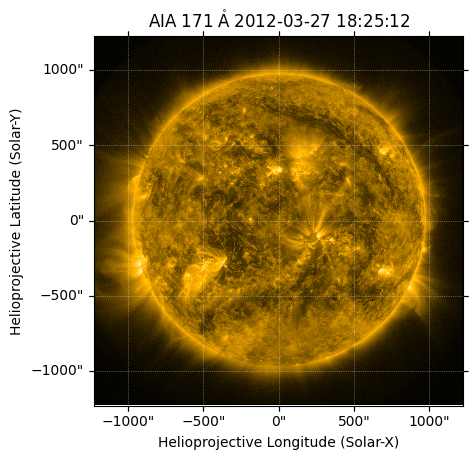

In [5]:
calibrate_sequence_map[0].plot()
plt.savefig('D:/work/wavelet/figure/aia171_fulldisk.png',dpi=300)

In [51]:
calibrate_sequence_submap[-30].fits_header['DATE-OBS']

'2012-03-27T18:39:24.348'

In [62]:
for i in range(np.shape(calibrate_sequence_submap)[0]):
    fig = plt.figure(figsize=(6,6))
    calibrate_sequence_submap[i].plot()
    plt.xlabel('x [arcsec]')
    plt.ylabel('y [arcsec]')
    plt.savefig('D:/work/wavelet/figure/aia_movie/'+str(i)+'.png',dpi=300)
    plt.close()

In [55]:
for i in range(np.shape(calibrate_sequence_submap)[0]):
    fig = plt.figure(figsize=(6,6))
    calibrate_sequence_submap[i].plot(vmin=-20,vmax=20)
    plt.xlabel('x [arcsec]')
    plt.ylabel('y [arcsec]')
    plt.savefig('D:/work/wavelet/figure/aia_movie_with_atrous/'+str(i)+'.png',dpi=300)
    plt.close()

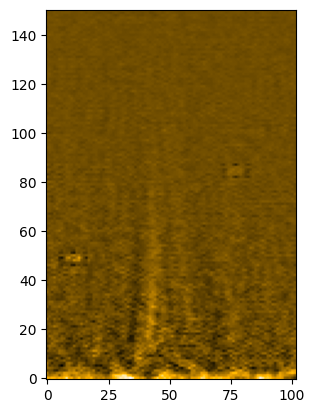

In [92]:
plt.imshow((input_data_3D[:,:,i].T), origin='lower',cmap='sdoaia171')

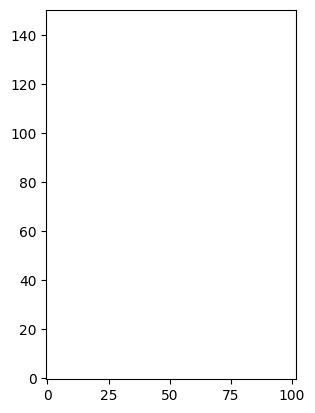

In [94]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
ims = []
fig = plt.figure()
for i in range(np.shape(input_data_3D)[2]):
    im = plt.imshow((input_data_3D[:,:,i].T), origin='lower',cmap='sdoaia171',vmax=10,vmin=-10).findobj()
    ims.append(im)
ani = animation.ArtistAnimation(fig, ims, interval=200, repeat_delay=1000)
ani.save("./test1_atrous.gif", writer='pillow')

In [95]:
np.shape(input_data_3D)

(102, 151, 101)

dict_keys(['__header__', '__version__', '__globals__', 'data', 'radial_arr', 'lambda_r_arr', 'lambda_t_arr', 'period_arr'])


Text(0, 0.5, '$\\omega$  $[Hz]$')

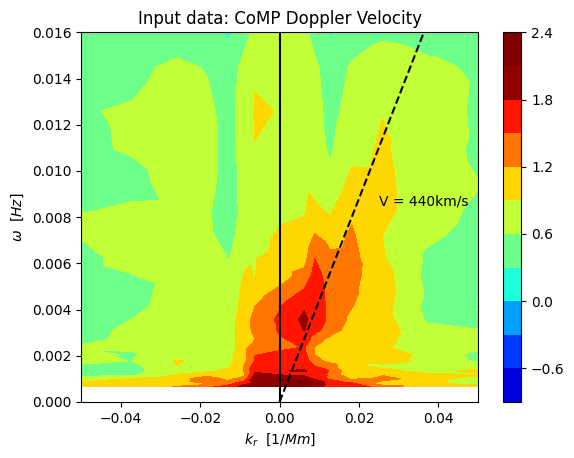

In [ ]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt

comp_fits_dir = 'D:/work/wavelet/data/comp/fits_20120327_morton/'
comp_fits_list = os.listdir(comp_fits_dir)
already_crop_data = False
ims = []
fig = plt.figure()
ax = plt.subplot()

for comp_fits in comp_fits_list:
    from astropy.io import fits
    hdul = fits.open(comp_fits_dir+comp_fits)
    obstime = hdul[0].header['DATE-OBS']+' '+hdul[0].header['TIME-OBS']
    # print(hdul.info())
    doppler_map = hdul[3].data
    if not already_crop_data:
        sequence_doppler_map = np.copy(doppler_map[530:590, 250:370])
        already_crop_data = True
    else:
        sequence_doppler_map = np.dstack([sequence_doppler_map, doppler_map[530:590, 250:370]])
    x = np.array(range(np.shape(doppler_map[530:590, 250:370])[1]))*4.46 + (250-310.5)*4.46
    y = np.array(range(np.shape(doppler_map[530:590, 250:370])[0]))*4.46 + (530-310.5)*4.46
    im = plt.pcolor(x,y,doppler_map[530:590, 250:370],cmap='seismic',vmin=-10, vmax=10).findobj()
    plt.xlabel('x [arcsec]')
    plt.ylabel('y [arcsec]')
    
    ims.append(im)
    # plt.cla()
plt.colorbar(label='km/s')
ani = animation.ArtistAnimation(fig, ims, interval=100, repeat_delay=1000)
ani.save("./0327_morton_test_comp.gif", writer='pillow')



# wavelet map sequence
input_data_3D = np.transpose(sequence_doppler_map, (1,0,2))
calculate_wavelet_2DT_GPU(input_data_3D=input_data_3D)

# combine wavelet results
azimuth_degree = 358 # 358
radial_Rs = 1.05 # can be ignored

combine_wavelet_output(azimuth_degree, radial_Rs)

# visualize results
wavelet_output_combined_data = loadmat('D:/work/wavelet/data/wavelet_output_combined/combined_wavelet_output_azimuth_358_radial_1.05.mat')
wavelet_output_data = wavelet_output_combined_data['data']
print(wavelet_output_combined_data.keys())
lambda_r_arr = wavelet_output_combined_data['lambda_r_arr'][-1]
period_arr = wavelet_output_combined_data['period_arr'][-1]

omega_arr = 1/(period_arr/12*30)
wavevector_arr = 1/(lambda_r_arr * 4.46 * 0.721)
# wavelet_ouput_plot = np.log10(np.percentile(wavelet_output_data[40:110, 10:30, :, :], axis=(0, 1), q=60))
wavelet_ouput_plot = np.log10(np.mean(wavelet_output_data[5:, 50:150, :, :], axis=(0,1)))#-np.log10(np.mean(wavelet_output_data[22, 110:120, :, :], axis=(0)))
# wavelet_ouput_plot = (np.mean(wavelet_output_data[:,:, :, :], axis=(0,1)))
# wavelet_ouput_plot = np.log10(np.mean(wavelet_output_data[:,:, :, :], axis=(0, 1)))
# wavelet_ouput_plot = np.log10(wavelet_output_data[50, 20, :, :])
wavevector_grid, omega_grid = np.meshgrid(wavevector_arr, omega_arr, indexing='ij')
ax = plt.subplot()
plt.tricontourf(wavevector_grid.reshape(-1), omega_grid.reshape(-1), wavelet_ouput_plot.reshape(-1), cmap='jet',levels=10, vmax=2,vmin=-1)
plt.colorbar()
plt.ylim([0,0.016])
plt.xlim([-0.05,0.05])
plt.plot(np.array([0,0]),np.array([0,0.2]),'k')
k = 0.44
plt.plot(np.array([0,0.2]),k*np.array([0,0.2]),'k--')
# plt.yscale('log')
# plt.xscale('symlog')
# plt.title('r = ' + '%3.2f'%(sub_radial_Rs_arr[90]) + ' Rs')
plt.title('Input data: CoMP Doppler Velocity')
plt.text(0.025,0.0085,'V = 440km/s',color='k')
plt.xlabel(r'$k_{r}$  $ [1/Mm]$')
plt.ylabel(r'$\omega$  $[Hz]$')
# plt.pcolor(wavevector_arr,omega_arr,wavelet_ouput_plot, cmap='jet')
# plt.savefig('D:/work/wavelet/figure/CoMP_wavelet.png',dpi=300,bbox_inches='tight')
# ax.set_aspect(50)
    

In [12]:
import numpy as np
from scipy.ndimage import maximum_filter
from scipy.ndimage import generate_binary_structure, binary_erosion
import matplotlib.pyplot as plt
%matplotlib inline

def detect_peaks(image):
    """
    Takes an image and detect the peaks usingthe local maximum filter.
    Returns a boolean mask of the peaks (i.e. 1 when
    the pixel's value is the neighborhood maximum, 0 otherwise)
    """

    # define an 8-connected neighborhood
    neighborhood = np.ones((3,3))

    #apply the local maximum filter; all pixel of maximal value 
    #in their neighborhood are set to 1
    local_max = maximum_filter(image, footprint=neighborhood)==image
    #local_max is a mask that contains the peaks we are 
    #looking for, but also the background.
    #In order to isolate the peaks we must remove the background from the mask.

    #we create the mask of the background
    background = (image==0)

    #a little technicality: we must erode the background in order to 
    #successfully subtract it form local_max, otherwise a line will 
    #appear along the background border (artifact of the local maximum filter)
    eroded_background = binary_erosion(background, structure=neighborhood, border_value=1)

    #we obtain the final mask, containing only peaks, 
    #by removing the background from the local_max mask (xor operation)
    detected_peaks = local_max ^ eroded_background

    return detected_peaks


#applying the detection and plotting results
detected_peaks = detect_peaks(wavelet_ouput_plot)
detected_peaks[wavelet_ouput_plot<1.0]=0
detected_peaks[wavelet_ouput_plot>2.0]=0
# plt.imshow(wavelet_ouput_plot)
# # pp.subplot(4,2,(2*i+2))
# pp.imshow(detected_peaks)
plt.tricontourf(wavevector_grid.reshape(-1), omega_grid.reshape(-1), wavelet_ouput_plot.reshape(-1), cmap='jet',levels=30, vmax=2,vmin=-2)
plt.plot(np.array([0,0.03]),0.44*np.array([0,0.03]),'k--')
# plt.ylim([0,0.016])
# plt.xlim([-0.1,0.1])
plt.show()

NameError: name 'wavelet_ouput_plot' is not defined

In [ ]:
1/0.006 * 5 /720 / 0.6

In [ ]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
# def update(frame):
#     x = np.linspace(0, 2*np.pi, 100)
#     y = np.sin(x + frame/10) + np.random.randn(100)/10
#     line.set_ydata(y)
#     fig.suptitle("动画更新的标题：frame=%d" % frame)
#     return line, fig
def update(frame):
    comp_fits_dir = 'D:/work/wavelet/data/comp/fits/'
    comp_fits_list = os.listdir(comp_fits_dir)
    comp_fits = comp_fits_list[frame]
    from astropy.io import fits
    hdul = fits.open(comp_fits_dir+comp_fits)
    obstime = hdul[0].header['DATE-OBS']+' '+hdul[0].header['TIME-OBS']
    # print(hdul.info())
    doppler_map = hdul[3].data
    
    im = plt.imshow(doppler_map, origin='lower',cmap='seismic',vmin=-10,vmax=10)#.findobj()
    fig.suptitle(obstime)
    print(obstime)
    hdul.close()
    return im, fig
        # plt.cla()
fig = plt.figure()
ani = FuncAnimation(fig, update, frames=60, interval=100, blit=True)
ani.save("./test_comp.gif", writer='pillow')
    

In [ ]:
fig = plt.figure(figsize=(10,5))
time = np.array(range(np.shape(input_data_3D)[2]))*30
r = np.array(range(np.shape(input_data_3D)[1]))*4.46 + (530-310)*4.46
plt.imshow( input_data_3D[50, :, :], vmin=-10, vmax=10, cmap='seismic',origin='lower')
plt.xlabel('Time [s] [since 2012-03-27 18:01:21]')
plt.ylabel('y [arcsec]')
np.shape(sequence_doppler_map)
plt.colorbar(label='km/s')
plt.title('x = 89 arcsec')
# plt.savefig('D:/work/wavelet/figure/dopper_velocity_Jmap.png',dpi=300)

In [ ]:
1/np.sort(1/np.linspace(-100, 100, 10))

In [ ]:
hdul = fits.open('C:/Users/hcp/Desktop/20120327.comp.1074.quick_invert.fts/20120327.comp.1074.quick_invert.fts')
print(hdul.info())
# doppler_map = hdul[3].data

In [ ]:
a = sunpy.map.Map('D:/work/wavelet/data/AIA/171/aia.lev1_euv_12s.2012-03-27T185113Z.171.image_lev1.fits')
plt.imshow(a.data,origin='lower')

In [ ]:
import gzip
import os
def decompress_gz_filelist(filelist, file_dir):
    for file in filelist:
        # file = "D:/work/wavelet/data/comp/20120328.comp.1074.daily_dynamics.3/20120328.230302.comp.1074.dynamics.3.fts.gz"
        f_gzip = gzip.GzipFile(file_dir+file, "rb")
        decompress_file = 'D:/work/wavelet/data/comp/fits/'+file.replace('.gz','')
        print(decompress_file)
        f_in = open(decompress_file,"wb")
        f_in.write(f_gzip.read())
        f_in.close()
        f_gzip.close()
comp_gz_dir = 'D:/work/wavelet/data/comp/20120329.comp.1074.daily_dynamics.3/'
comp_gz_filelist = os.listdir(comp_gz_dir) 
decompress_gz_filelist(comp_gz_filelist, comp_gz_dir)

In [ ]:
import gzip
import os
def decompress_gz_filelist(filelist, file_dir):
    for file in filelist:
        # file = "D:/work/wavelet/data/comp/20120328.comp.1074.daily_dynamics.3/20120328.230302.comp.1074.dynamics.3.fts.gz"
        f_gzip = gzip.GzipFile(file_dir+file, "rb")
        decompress_file = 'D:/work/wavelet/data/comp/fits_20120327/'+file.replace('.gz','')
        print(decompress_file)
        f_in = open(decompress_file,"wb")
        f_in.write(f_gzip.read())
        f_in.close()
        f_gzip.close()
comp_gz_dir = 'D:/work/wavelet/data/comp/20120327.comp.1074.l2/'
comp_gz_filelist = os.listdir(comp_gz_dir) 
decompress_gz_filelist(comp_gz_filelist, comp_gz_dir)

In [ ]:

#coding=utf-8
import os
import shutil
import traceback
 
 
def move_file(src_path, dst_path, file):
    try:
        # cmd = 'chmod -R +x ' + src_path
        # os.popen(cmd)
        f_src = os.path.join(src_path, file)
        if not os.path.exists(dst_path):
            os.mkdir(dst_path)
        f_dst = os.path.join(dst_path, file)
        shutil.move(f_src, f_dst)
    except Exception as e:
        print('move_file ERROR: ',e)

src_path = 'D:/work/wavelet/data/comp/fits/'
dst_path = 'D:/work/wavelet/data/comp/fits_20120329/'
filelist = os.listdir(src_path)
for file in filelist:
    if  ("dynamics" in file) and ("20120329.20" in file):
        move_file(src_path, dst_path, file)

        

In [ ]:
filelist = os.listdir(dst_path)

In [ ]:
input_data = calibrate_sequence_map[0].data
output_w = a_trous_wavelet_2D(input_data, level_num=4, method='B_spline')
enhenced_sequence_data = output_w[:,:,1] + output_w[:,:,2] 
a = sunpy.map.Map(enhenced_sequence_data,calibrate_sequence_map[0].fits_header)
plt.imshow((enhenced_sequence_data),origin='lower',cmap='sdoaia171',vmin=-10,vmax=10)


In [ ]:
plt.imshow((subsequence_data[:,:,0]),origin='lower',cmap='sdoaia171',vmin=-10,vmax=10)

In [ ]:
lambda_r_arr = np.logspace(np.log10(20), np.log10(600), 10, base=10) ### modified by user
lambda_t_arr = np.logspace(np.log10(2), np.log10(50), 10, base=10) ### modified by user
period_arr = np.logspace(np.log10(72),np.log10(1000), 24, base=10) ### modified by user

lambda_r_arr = np.hstack((np.flip(-lambda_r_arr), lambda_r_arr))
lambda_t_arr = np.hstack((np.flip(-lambda_t_arr), lambda_t_arr))

In [ ]:
(110*1.2+970)/960

In [ ]:

# visualize results
wavelet_output_combined_data = loadmat('D:/work/wavelet/data/wavelet_output_combined/combined_wavelet_output_azimuth_0.3_radial_1.05.mat')
wavelet_output_data = wavelet_output_combined_data['data']
print(wavelet_output_combined_data.keys())
lambda_r_arr = wavelet_output_combined_data['lambda_r_arr'][-1]
period_arr = wavelet_output_combined_data['period_arr'][-1]

omega_arr = 1/(period_arr)
wavevector_arr = 1/(lambda_r_arr * 0.0012445220250452197/2 * 695)
wavelet_ouput_plot = np.log10(np.mean(wavelet_output_data[:,:, :, :], axis=(0,1)))
# wavelet_ouput_plot = np.log10(wavelet_output_data[80, 20, :, :])
wavevector_grid, omega_grid = np.meshgrid(wavevector_arr, omega_arr, indexing='ij')
ax = plt.subplot()
plt.tripcolor(wavevector_grid.reshape(-1), omega_grid.reshape(-1), wavelet_ouput_plot.reshape(-1), cmap='jet')
# plt.ylim([0.00225,0.025])
# plt.xlim([-0.08,0.08])
# plt.yscale('log')
# plt.xscale('symlog')
# plt.title('r = ' + '%3.2f'%(sub_radial_Rs_arr[90]) + ' Rs')
plt.xlabel(r'$k_{r}$  $ [2\pi/R_s]$')
plt.ylabel(r'$\omega$  $[2\pi/s]$')
# plt.pcolor(wavevector_arr,omega_arr,wavelet_ouput_plot, cmap='jet')
# ax.axes_ratio('square')

In [ ]:
new_map.plot()
a,b,c = get_submap_data(357,4,1.01,1.1,new_map)


In [ ]:
plt.imshow(c,origin='lower',cmap='sdoaia171')

In [ ]:
plt.imshow(subsequence_data[:,:,45],origin='lower',cmap='sdoaia171')

In [ ]:

# crop map sequence
sub_radial_Rs_arr, sub_azimuth_arr, sequence_map_datetime, subsequence_data =\
            crop_lasco_map(projected_sequence, deg_min=340, deg_max=20, r_min=1.005, r_max=1.2)

# save croped map sequence
save_current_crop_sequence_data(sub_radial_Rs_arr, sub_azimuth_arr, subsequence_data)

load_data_file = loadmat("D:/work/wavelet/data/wavelet_input/wavelet_input_aia171.mat")
input_data_3D = load_data_file['data'][...]
input_data_3D[input_data_3D<0]=1e-2
input_data_3D = np.sqrt(input_data_3D)

In [ ]:
plt.imshow(input_data_3D[:,:,25],origin='lower',cmap='sdoaia171',vmax=30)

In [ ]:
sequence_raw[45].plot(vmax=1500)
%matplotlib inline
plt.show()

In [ ]:
np.shape(wavelet_output_data)

In [ ]:
calibrate_map(sequence_raw[10]) 

In [ ]:
 lambda_r_arr = np.logspace(np.log10(2),np.log10(200), 10, base=10)

In [ ]:
lambda_r_arr

In [ ]:
# crop map sequence
sub_radial_Rs_arr, sub_azimuth_arr, sequence_map_datetime, subsequence_data =\
            crop_lasco_map(projected_sequence, deg_min=350, deg_max=10, r_min=1.005, r_max=1.15)


In [ ]:
sub_radial_Rs_arr

In [ ]:
lambda_r_arr = np.logspace(np.log10(2),np.log10(150), 10, base=10) ### modified by user
lambda_t_arr = np.logspace(np.log10(2),np.log10(150), 10, base=10) ### modified by user
period_arr = np.logspace(np.log10(36),np.log10(600), 20, base=10) ### modified by user

lambda_r_arr = np.hstack((np.flip(-lambda_r_arr), lambda_r_arr))
lambda_t_arr = np.hstack((np.flip(-lambda_t_arr), lambda_t_arr))
period_arr=  np.append(period_arr, -2*np.pi/0.01)

In [ ]:
lambda_r_arr

In [ ]:
def get_parameter_index_in_np_array(array, sub_array):
    sub_idx = np.array([],dtype=int)
    for i in sub_array:
        idx_temp = int(np.argmin(np.abs(array-i)))
        if np.abs(array[idx_temp] - i)<1e-3:
            sub_idx = np.append(sub_idx, idx_temp)
        else:
            print('Wrong: get_parameter_index_in_np_array!')
        
    return sub_idx

In [ ]:
array = np.array(range(10))
sub_array = np.array(range(3))
get_parameter_index_in_np_array(array, sub_array)

In [ ]:
lambda_t_arr = np.logspace(np.log10(2),np.log10(50), 10, base=10) 

In [ ]:
lambda_t_arr